<a href="https://colab.research.google.com/github/dhruvmenon76/Pneumonia-Detection-Under-Imaging-Constraints/blob/main/BME548_BlurDataSets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pneumonia Detection — Blurred Dataset Generation

## 1: Clone Repo

In [1]:
!git clone https://github.com/dhruvmenon76/Pneumonia-Detection-Under-Imaging-Constraints.git
!ls Pneumonia-Detection-Under-Imaging-Constraints/data

Cloning into 'Pneumonia-Detection-Under-Imaging-Constraints'...
remote: Enumerating objects: 5925, done.
remote: Counting objects: 100% (72/72), done.
remote: Compressing objects: 100% (62/62), done.
remote: Total 5925 (delta 25), reused 38 (delta 8), pack-reused 5853 (from 1)
Receiving objects: 100% (5925/5925), 1.16 GiB | 37.79 MiB/s, done.
Resolving deltas: 100% (30/30), done.
Updating files: 100% (5883/5883), done.
test  train  val


## 2: Imports & Load Data

In [2]:
import sys, os
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

%cd Pneumonia-Detection-Under-Imaging-Constraints
sys.path.append(os.path.abspath('src'))
from dataset_generation import get_dataloaders

BASE_PATH = '/content/Pneumonia-Detection-Under-Imaging-Constraints/data'
print('Folders in data:', os.listdir(BASE_PATH))

train_loader, val_loader, test_loader = get_dataloaders(BASE_PATH, batch_size=32)
print('Train:', len(train_loader.dataset))
print('Val  :', len(val_loader.dataset))
print('Test :', len(test_loader.dataset))

/content/Pneumonia-Detection-Under-Imaging-Constraints
Folders in data: ['train', 'val', '.DS_Store', 'test']
Train: 5216
Val  : 16
Test : 624


## 3: Visualise a Batch

Batch shape: torch.Size([32, 3, 224, 224])


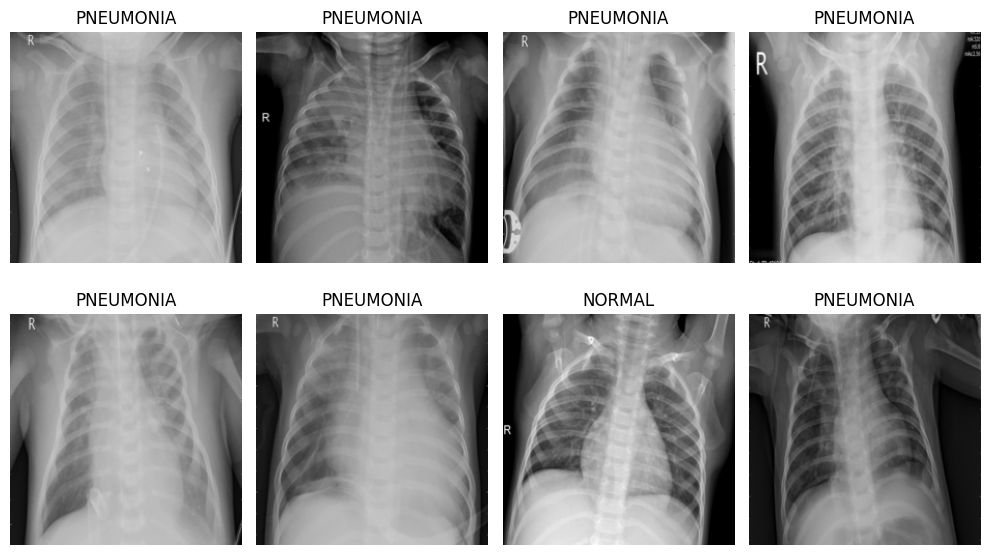

In [3]:
images, labels = next(iter(train_loader))
print('Batch shape:', images.shape)

def imshow(img):
    img = img.permute(1, 2, 0) * 0.5 + 0.5
    plt.imshow(img)
    plt.axis('off')

plt.figure(figsize=(10, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    imshow(images[i])
    plt.title('PNEUMONIA' if labels[i].item() == 1 else 'NORMAL')
plt.tight_layout()
plt.show()

## 4: Class Distribution

In [4]:
def print_class_dist(loader, name):
    lbl = np.array(loader.dataset.labels)
    total = len(lbl)
    n = np.sum(lbl == 0)
    p = np.sum(lbl == 1)
    print(f'\n{name} SET  total={total}  NORMAL={n} ({n/total:.1%})  PNEUMONIA={p} ({p/total:.1%})')

print_class_dist(train_loader, 'TRAIN')
print_class_dist(val_loader,   'VAL')
print_class_dist(test_loader,  'TEST')


TRAIN SET  total=5216  NORMAL=1341 (25.7%)  PNEUMONIA=3875 (74.3%)

VAL SET  total=16  NORMAL=8 (50.0%)  PNEUMONIA=8 (50.0%)

TEST SET  total=624  NORMAL=234 (37.5%)  PNEUMONIA=390 (62.5%)


## 5: Blur Demo (single image, all 3 levels)

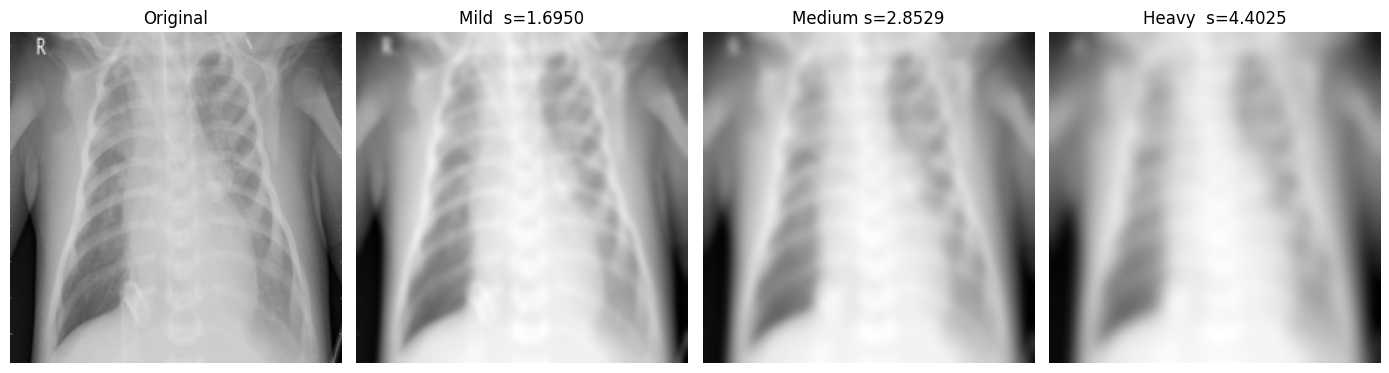

In [5]:
import cv2

def gaussian_kernel(size, sigma):
    ax = np.linspace(-(size // 2), size // 2, size)
    xx, yy = np.meshgrid(ax, ax)
    k = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    return k / k.sum()

def to_gray(t):
    return np.mean(t.cpu().permute(1, 2, 0).numpy(), axis=2)

img_gray = to_gray(images[4])
configs  = [('Mild  s=1.6950', 1.6950), ('Medium s=2.8529', 2.8529), ('Heavy  s=4.4025', 4.4025)]

plt.figure(figsize=(14, 4))
plt.subplot(1, 4, 1); plt.title('Original'); plt.imshow(img_gray, cmap='gray'); plt.axis('off')
for idx, (title, sigma) in enumerate(configs, 2):
    blurred = cv2.GaussianBlur(img_gray.astype(np.float32), (0, 0), sigmaX=sigma, sigmaY=sigma)
    plt.subplot(1, 4, idx)
    plt.title(title)
    plt.imshow(blurred, cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.show()

## 6: Generate All 3 Blurred Datasets
Creates `data/blur_mild/`, `data/blur_medium/`, `data/blur_heavy/` each with `train/val/test` and `NORMAL/PNEUMONIA` sub-folders.
Safe to re-run (skips files that already exist).

In [6]:
BLUR_LEVELS = {
    'blur_mild':   {'sigma': 1.6950},
    'blur_medium': {'sigma': 2.8529},
    'blur_heavy':  {'sigma': 4.4025},
}
SPLITS  = ['train', 'val', 'test']
CLASSES = ['NORMAL', 'PNEUMONIA']

def blur_pil(img, params):
    img = img.resize((224, 224), Image.LANCZOS)
    arr = np.array(img)
    blurred = cv2.GaussianBlur(arr, (0, 0), sigmaX=params['sigma'], sigmaY=params['sigma'])
    return Image.fromarray(blurred)

def generate(base_path, overwrite=True):
    base = Path(base_path)
    for level, params in BLUR_LEVELS.items():
        print(f"\n{'='*55}\n  {level}  sigma={params['sigma']}\n{'='*55}")
        for split in SPLITS:
            for cls in CLASSES:
                src = base / split / cls
                dst = base / level / split / cls
                dst.mkdir(parents=True, exist_ok=True)
                files = list(src.glob('*.jpeg')) + list(src.glob('*.jpg')) + list(src.glob('*.png'))
                if not files:
                    continue
                print(f'  {split}/{cls}  {len(files)} images')
                for i, fp in enumerate(files, 1):
                    out = dst / fp.name
                    if not out.exists() or overwrite:
                        blur_pil(Image.open(fp).convert('RGB'), params).save(out)
                    if i % 200 == 0 or i == len(files):
                        print(f'    {i}/{len(files)}', end='\r')
                print()
        print(f'  {level} done.')
    print('\nAll 3 blurred datasets created!')

BASE_PATH = '/content/Pneumonia-Detection-Under-Imaging-Constraints/data'
generate(BASE_PATH)


  blur_mild  sigma=1.695
  train/NORMAL  1341 images
    1341/1341
  train/PNEUMONIA  3875 images
    3875/3875
  val/NORMAL  8 images
    8/8
  val/PNEUMONIA  8 images
    8/8
  test/NORMAL  234 images
    234/234
  test/PNEUMONIA  390 images
    390/390
  blur_mild done.

  blur_medium  sigma=2.8529
  train/NORMAL  1341 images
    1341/1341
  train/PNEUMONIA  3875 images
    3875/3875
  val/NORMAL  8 images
    8/8
  val/PNEUMONIA  8 images
    8/8
  test/NORMAL  234 images
    234/234
  test/PNEUMONIA  390 images
    390/390
  blur_medium done.

  blur_heavy  sigma=4.4025
  train/NORMAL  1341 images
    1341/1341
  train/PNEUMONIA  3875 images
    3875/3875
  val/NORMAL  8 images
    8/8
  val/PNEUMONIA  8 images
    8/8
  test/NORMAL  234 images
    234/234
  test/PNEUMONIA  390 images
    390/390
  blur_heavy done.

All 3 blurred datasets created!


## 7: Verify Counts

In [7]:
def count(path):
    p = Path(path)
    return len(list(p.glob('*.jpeg')) + list(p.glob('*.jpg')) + list(p.glob('*.png')))

base = Path(BASE_PATH)
datasets = ['original'] + list(BLUR_LEVELS.keys())
print(f"{'Dataset':<20} {'Split':<8} {'NORMAL':>8} {'PNEUMONIA':>12} {'Total':>8}")
print('='*60)
for ds in datasets:
    for split in SPLITS:
        prefix = base if ds == 'original' else base / ds
        n = count(prefix / split / 'NORMAL')
        p = count(prefix / split / 'PNEUMONIA')
        print(f'{ds:<20} {split:<8} {n:>8} {p:>12} {n+p:>8}')
    print('-'*60)

Dataset              Split      NORMAL    PNEUMONIA    Total
original             train        1341         3875     5216
original             val             8            8       16
original             test          234          390      624
------------------------------------------------------------
blur_mild            train        1341         3875     5216
blur_mild            val             8            8       16
blur_mild            test          234          390      624
------------------------------------------------------------
blur_medium          train        1341         3875     5216
blur_medium          val             8            8       16
blur_medium          test          234          390      624
------------------------------------------------------------
blur_heavy           train        1341         3875     5216
blur_heavy           val             8            8       16
blur_heavy           test          234          390      624
------------------------

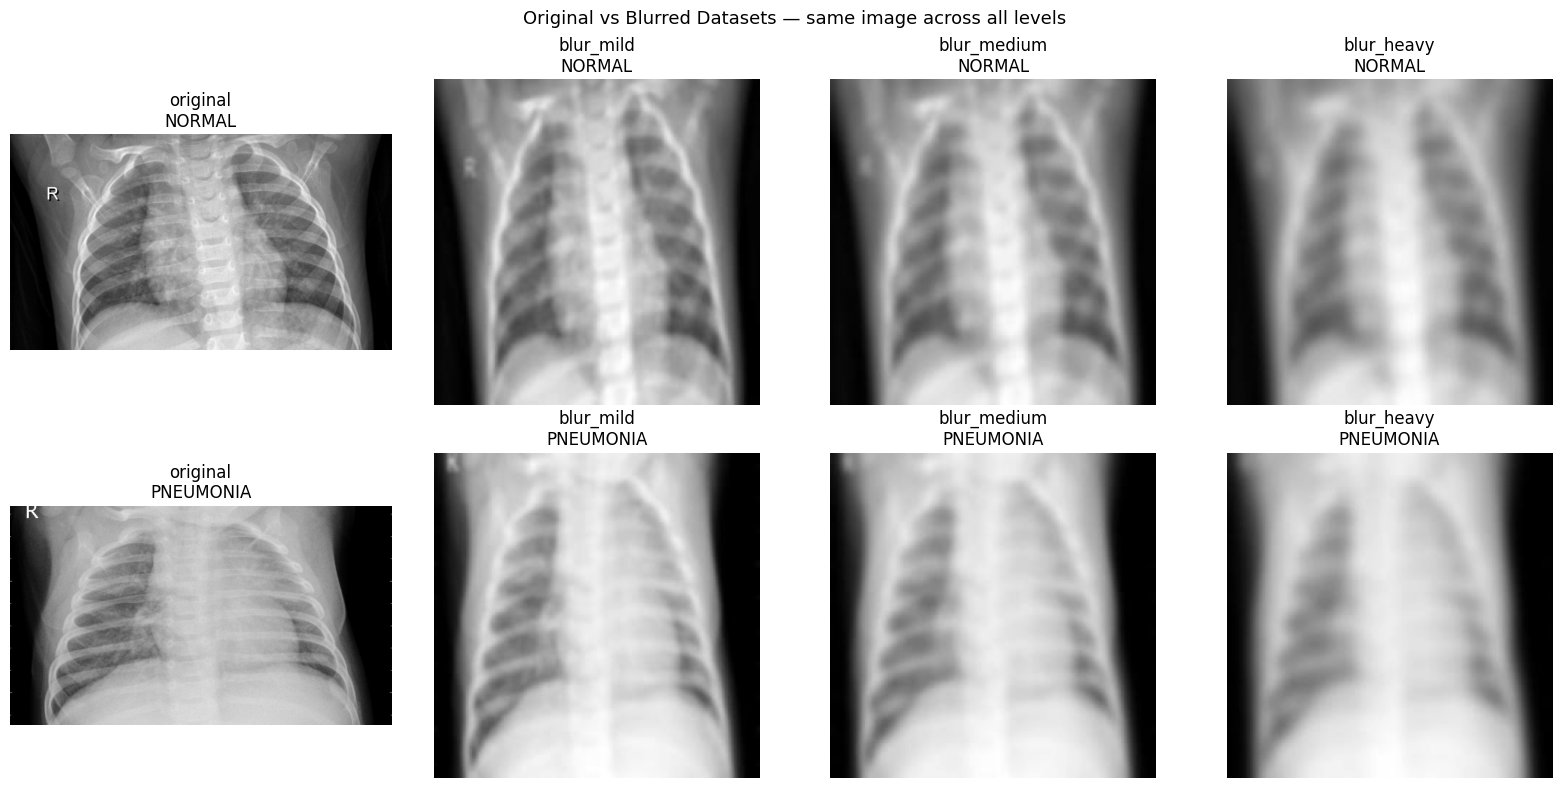

In [8]:
BASE = '/content/Pneumonia-Detection-Under-Imaging-Constraints/data'

# Pick one image from NORMAL and one from PNEUMONIA
sample_normal    = list((Path(BASE) / 'test' / 'NORMAL').glob('*.jpeg'))[0]
sample_pneumonia = list((Path(BASE) / 'test' / 'PNEUMONIA').glob('*.jpeg'))[0]

datasets = ['original', 'blur_mild', 'blur_medium', 'blur_heavy']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for col, ds in enumerate(datasets):
    # NORMAL row
    path_n = Path(BASE) / ds / 'test' / 'NORMAL' / sample_normal.name if ds != 'original' else sample_normal
    axes[0, col].imshow(Image.open(path_n).convert('L'), cmap='gray')
    axes[0, col].set_title(f'{ds}\nNORMAL')
    axes[0, col].axis('off')

    # PNEUMONIA row
    path_p = Path(BASE) / ds / 'test' / 'PNEUMONIA' / sample_pneumonia.name if ds != 'original' else sample_pneumonia
    axes[1, col].imshow(Image.open(path_p).convert('L'), cmap='gray')
    axes[1, col].set_title(f'{ds}\nPNEUMONIA')
    axes[1, col].axis('off')

plt.suptitle('Original vs Blurred Datasets — same image across all levels', fontsize=13)
plt.tight_layout()
plt.show()

## 8: Training Model from Github


In [9]:
import copy, time
import torch.nn as nn
import torch.optim as optim
from torchvision.models import densenet121
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)

sys.path.append(os.path.abspath('src'))
from dataset_generation import get_dataloaders

base_path  = '/content/Pneumonia-Detection-Under-Imaging-Constraints/data'
device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
batch_size = 32
num_epochs = 8
lr         = 1e-4

# Load CLEAN original data for training
train_loader, val_loader, test_loader = get_dataloaders(base_path, batch_size=batch_size)

# Class weights
train_labels    = np.array(train_loader.dataset.labels)
num_normal      = np.sum(train_labels == 0)
num_pneumonia   = np.sum(train_labels == 1)
total           = len(train_labels)
class_weights   = torch.tensor(
    [total / (2 * num_normal), total / (2 * num_pneumonia)],
    dtype=torch.float32
).to(device)

# Build DenseNet121
model = densenet121(weights=None)
model.classifier = nn.Linear(model.classifier.in_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

# Training loop
best_model_wts = copy.deepcopy(model.state_dict())
best_val_loss  = float('inf')

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total_seen = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        correct      += (torch.argmax(outputs, 1) == labels).sum().item()
        total_seen   += labels.size(0)

    # Check val loss to save best model
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            val_loss += criterion(model(images), labels).item() * images.size(0)
    val_loss /= len(val_loader.dataset)

    if val_loss < best_val_loss:
        best_val_loss  = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())

    print(f"Epoch {epoch+1:02d}/{num_epochs} | "
          f"Train Loss: {running_loss/len(train_loader.dataset):.4f} | "
          f"Train Acc: {correct/total_seen:.4f} | Val Loss: {val_loss:.4f}")

# Load best weights and save
model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), 'best_model.pth')
print("\nModel trained and saved to best_model.pth")

Epoch 01/8 | Train Loss: 0.2203 | Train Acc: 0.9072 | Val Loss: 1.9507
Epoch 02/8 | Train Loss: 0.1214 | Train Acc: 0.9567 | Val Loss: 0.4838
Epoch 03/8 | Train Loss: 0.0717 | Train Acc: 0.9745 | Val Loss: 0.1662
Epoch 04/8 | Train Loss: 0.0715 | Train Acc: 0.9749 | Val Loss: 0.6304
Epoch 05/8 | Train Loss: 0.0446 | Train Acc: 0.9841 | Val Loss: 0.7376
Epoch 06/8 | Train Loss: 0.0285 | Train Acc: 0.9895 | Val Loss: 0.2142
Epoch 07/8 | Train Loss: 0.0332 | Train Acc: 0.9893 | Val Loss: 0.2839
Epoch 08/8 | Train Loss: 0.0323 | Train Acc: 0.9896 | Val Loss: 0.0461

Model trained and saved to best_model.pth


## 9: Testing on Blurred Datasets


clean    | Acc=0.7644 | F1=0.8411 | AUC=0.8780 | Recall=0.9974
mild     | Acc=0.6619 | F1=0.7858 | AUC=0.8381 | Recall=0.9923
medium   | Acc=0.6314 | F1=0.7714 | AUC=0.7993 | Recall=0.9949
heavy    | Acc=0.6250 | F1=0.7692 | AUC=0.8005 | Recall=1.0000

Dataset      Accuracy       F1      AUC   Recall  Precision    Bal Acc
clean          0.7644   0.8411   0.8780   0.9974     0.7271     0.6868
mild           0.6619   0.7858   0.8381   0.9923     0.6504     0.5517
medium         0.6314   0.7714   0.7993   0.9949     0.6299     0.5103
heavy          0.6250   0.7692   0.8005   1.0000     0.6250     0.5000


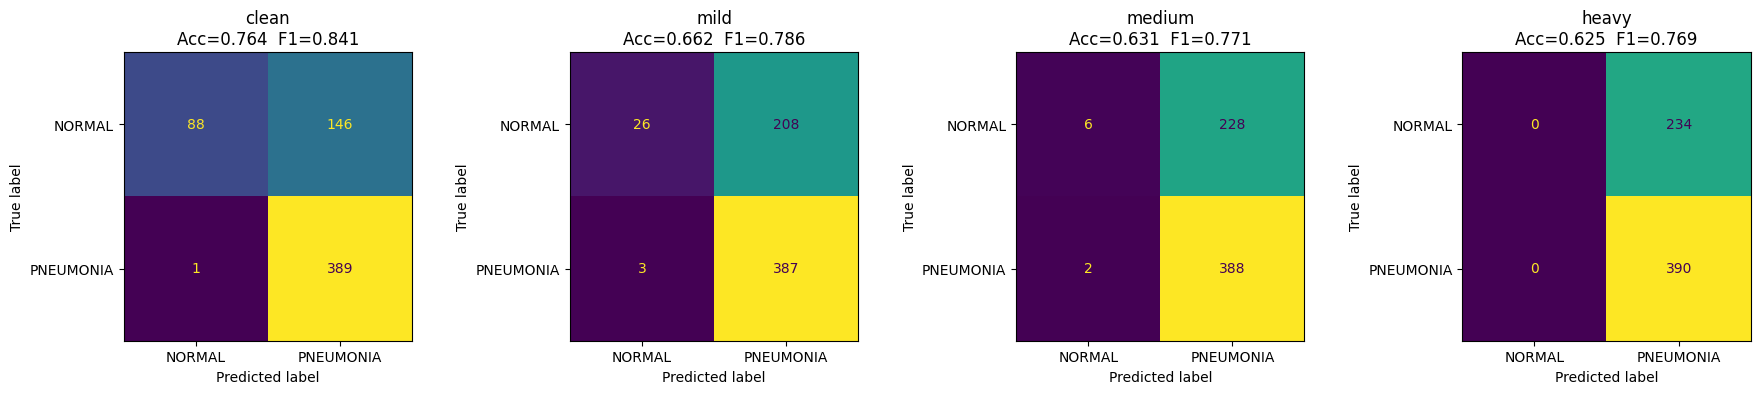

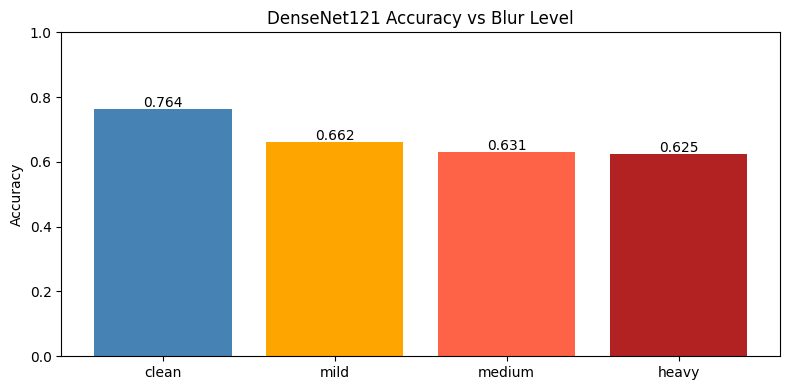

In [10]:
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.metrics import ConfusionMatrixDisplay, balanced_accuracy_score

# Blur transform
class GaussianBlurTransform:
    def __init__(self, sigma=0.0, image_size=(224, 224)):
        self.sigma      = sigma
        self.image_size = image_size

    def __call__(self, img):
        img = img.resize(self.image_size, Image.LANCZOS)
        if self.sigma == 0.0:
            return img
        arr     = np.array(img)
        blurred = cv2.GaussianBlur(arr, (0, 0), sigmaX=self.sigma, sigmaY=self.sigma)
        return Image.fromarray(blurred)

def build_blur_transform(sigma):
    return transforms.Compose([
        GaussianBlurTransform(sigma=sigma),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ])

def clone_with_transform(dataset, transform):
    ds = copy.deepcopy(dataset)
    ds.transform = transform
    return ds

# Evaluation function
def evaluate(model, loader):
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            probs   = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
            preds   = torch.argmax(outputs, dim=1).cpu().numpy()
            all_labels.extend(labels.numpy())
            all_preds.extend(preds)
            all_probs.extend(probs)
    all_labels = np.array(all_labels)
    all_preds  = np.array(all_preds)
    return {
        'accuracy':  accuracy_score(all_labels, all_preds),
        'f1':        f1_score(all_labels, all_preds, zero_division=0),
        'recall':    recall_score(all_labels, all_preds, zero_division=0),
        'precision': precision_score(all_labels, all_preds, zero_division=0),
        'auc':       roc_auc_score(all_labels, all_probs),
        'cm':        confusion_matrix(all_labels, all_preds),
        'bal_acc':   balanced_accuracy_score(all_labels, all_preds),
    }

# Run evaluation across all blur levels
blur_levels = {'clean': 0.0, 'mild': 1.6950, 'medium': 2.8529, 'heavy': 4.4025}
results     = {}

for name, sigma in blur_levels.items():
    transform   = build_blur_transform(sigma)
    test_ds     = clone_with_transform(test_loader.dataset, transform)
    test_dl     = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)
    results[name] = evaluate(model, test_dl)
    print(f"{name:<8} | Acc={results[name]['accuracy']:.4f} | "
          f"F1={results[name]['f1']:.4f} | AUC={results[name]['auc']:.4f} | "
          f"Recall={results[name]['recall']:.4f}")

# Summary table
print(f"\n{'Dataset':<10} {'Accuracy':>10} {'F1':>8} {'AUC':>8} {'Recall':>8} {'Precision':>10} {'Bal Acc':>10}")
print('='*70)
for name, r in results.items():
    print(f"{name:<10} {r['accuracy']:>10.4f} {r['f1']:>8.4f} "
          f"{r['auc']:>8.4f} {r['recall']:>8.4f} {r['precision']:>10.4f} {r['bal_acc']:>10.4f}")

# Confusion matrices
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, r) in zip(axes, results.items()):
    ConfusionMatrixDisplay(r['cm'], display_labels=['NORMAL', 'PNEUMONIA']).plot(ax=ax, colorbar=False)
    ax.set_title(f"{name}\nAcc={r['accuracy']:.3f}  F1={r['f1']:.3f}")
plt.tight_layout()
plt.show()

# Accuracy drop bar chart
plt.figure(figsize=(8, 4))
names = list(results.keys())
accs  = [results[n]['accuracy'] for n in names]
bars  = plt.bar(names, accs, color=['steelblue', 'orange', 'tomato', 'firebrick'])
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.3f}', ha='center')
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('DenseNet121 Accuracy vs Blur Level')
plt.tight_layout()
plt.show()

# 10: Train and Testing with Blurred Datasets


 Training on: blur_mild
  Epoch 01/8 | Train Loss: 0.2048 | Train Acc: 0.9199 | Val Loss: 1.3471
  Epoch 02/8 | Train Loss: 0.1078 | Train Acc: 0.9595 | Val Loss: 0.1859
  Epoch 03/8 | Train Loss: 0.0876 | Train Acc: 0.9659 | Val Loss: 0.2235
  Epoch 04/8 | Train Loss: 0.0726 | Train Acc: 0.9755 | Val Loss: 0.4790
  Epoch 05/8 | Train Loss: 0.0464 | Train Acc: 0.9845 | Val Loss: 0.4812
  Epoch 06/8 | Train Loss: 0.0373 | Train Acc: 0.9870 | Val Loss: 0.1710
  Epoch 07/8 | Train Loss: 0.0384 | Train Acc: 0.9856 | Val Loss: 0.9301
  Epoch 08/8 | Train Loss: 0.0295 | Train Acc: 0.9898 | Val Loss: 0.2559
Saved best_model_blur_mild.pth
  Test → Acc=0.8333 | F1=0.8815 | AUC=0.9137 | Recall=0.9923

 Training on: blur_medium
  Epoch 01/8 | Train Loss: 0.2166 | Train Acc: 0.9172 | Val Loss: 0.3808
  Epoch 02/8 | Train Loss: 0.1122 | Train Acc: 0.9588 | Val Loss: 0.8036
  Epoch 03/8 | Train Loss: 0.0904 | Train Acc: 0.9668 | Val Loss: 0.9908
  Epoch 04/8 | Train Loss: 0.0686 | Train Acc: 0.9755

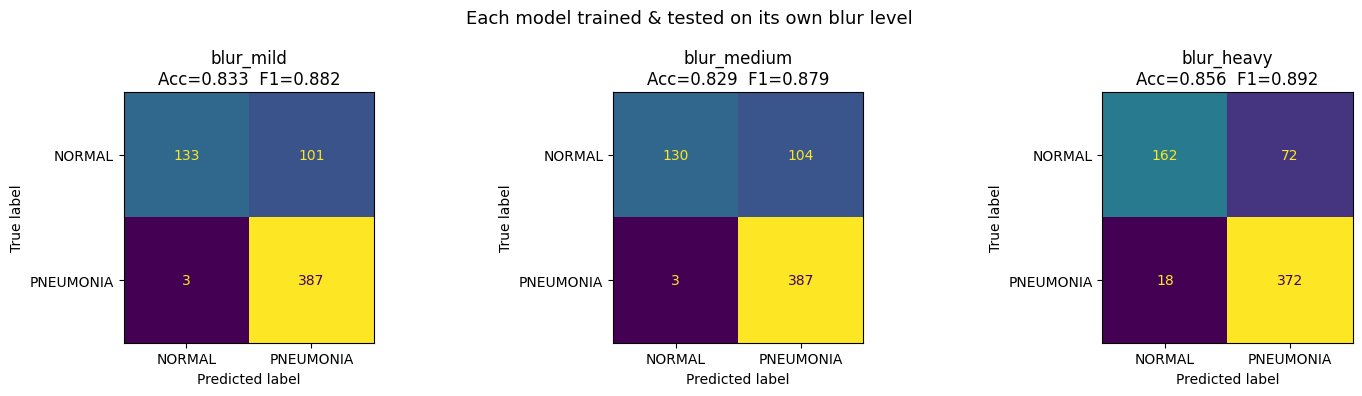

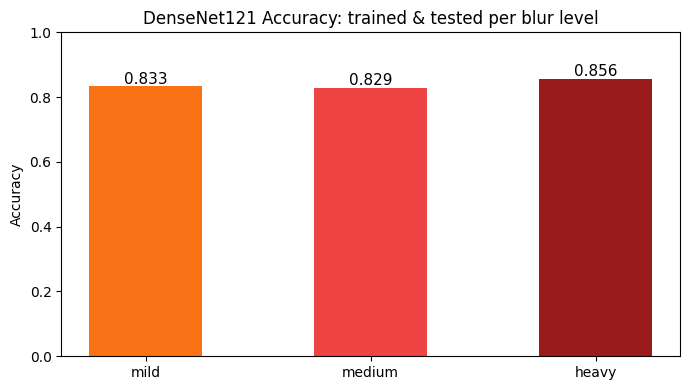

In [11]:
from torch.utils.data import Dataset

# Config
BASE_PATH  = '/content/Pneumonia-Detection-Under-Imaging-Constraints/data'
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 32
NUM_EPOCHS = 8
LR         = 1e-4
CLASSES    = ['NORMAL', 'PNEUMONIA']
SPLITS     = ['train', 'val', 'test']

BLUR_CONFIGS = {
    'blur_mild':   1.6950,
    'blur_medium': 2.8529,
    'blur_heavy':  4.4025,
}

# Dataset
class ChestXrayDataset(Dataset):
    def __init__(self, root, split, transform=None):
        self.transform = transform
        self.samples, self.labels = [], []
        for idx, cls in enumerate(CLASSES):
            folder = Path(root) / split / cls
            for ext in ('*.jpeg', '*.jpg', '*.png'):
                for fp in folder.glob(ext):
                    self.samples.append(fp)
                    self.labels.append(idx)

    def __len__(self): return len(self.samples)

    def __getitem__(self, i):
        img = Image.open(self.samples[i]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[i]

def make_transform():
    return transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ])

def make_loaders(data_root, batch_size=BATCH_SIZE):
    tf = make_transform()
    loaders = {}
    for split in SPLITS:
        ds = ChestXrayDataset(data_root, split, transform=tf)
        loaders[split] = DataLoader(
            ds, batch_size=batch_size,
            shuffle=(split == 'train'),
            num_workers=2, pin_memory=True)
    return loaders

# Model factory
def build_model():
    m = densenet121(weights=None)
    m.classifier = nn.Linear(m.classifier.in_features, 2)
    return m.to(DEVICE)

def class_weights(loader):
    lbl = np.array(loader.dataset.labels)
    n, p = np.sum(lbl == 0), np.sum(lbl == 1)
    total = len(lbl)
    return torch.tensor([total / (2*n), total / (2*p)],
                        dtype=torch.float32).to(DEVICE)

# Train
def train_model(loaders, tag):
    model     = build_model()
    cw        = class_weights(loaders['train'])
    criterion = nn.CrossEntropyLoss(weight=cw)
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

    best_wts      = copy.deepcopy(model.state_dict())
    best_val_loss = float('inf')

    print(f'\n{"="*60}\n Training on: {tag}\n{"="*60}')
    for epoch in range(NUM_EPOCHS):
        model.train()
        run_loss, correct, seen = 0.0, 0, 0
        for imgs, lbls in loaders['train']:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, lbls)
            loss.backward(); optimizer.step()
            run_loss += loss.item() * imgs.size(0)
            correct  += (torch.argmax(out, 1) == lbls).sum().item()
            seen     += lbls.size(0)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for imgs, lbls in loaders['val']:
                imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
                val_loss += criterion(model(imgs), lbls).item() * imgs.size(0)
        val_loss /= len(loaders['val'].dataset)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_wts = copy.deepcopy(model.state_dict())

        print(f"  Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
              f"Train Loss: {run_loss/seen:.4f} | "
              f"Train Acc: {correct/seen:.4f} | "
              f"Val Loss: {val_loss:.4f}")

    model.load_state_dict(best_wts)
    torch.save(model.state_dict(), f'best_model_{tag}.pth')
    print(f'Saved best_model_{tag}.pth')
    return model

# Evaluate
def evaluate(model, loader):
    model.eval()
    all_lbl, all_pred, all_prob = [], [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            out   = model(imgs.to(DEVICE))
            probs = torch.softmax(out, 1)[:, 1].cpu().numpy()
            preds = torch.argmax(out, 1).cpu().numpy()
            all_lbl.extend(lbls.numpy())
            all_pred.extend(preds)
            all_prob.extend(probs)
    y, p = np.array(all_lbl), np.array(all_pred)
    return dict(
        accuracy  = accuracy_score(y, p),
        f1        = f1_score(y, p, zero_division=0),
        recall    = recall_score(y, p, zero_division=0),
        precision = precision_score(y, p, zero_division=0),
        auc       = roc_auc_score(y, all_prob),
        bal_acc   = balanced_accuracy_score(y, p),
        cm        = confusion_matrix(y, p),
    )

# Main loop: train + test each blur level
results = {}

for tag in BLUR_CONFIGS:
    data_root      = Path(BASE_PATH) / tag
    loaders        = make_loaders(data_root)
    model          = train_model(loaders, tag)
    results[tag]   = evaluate(model, loaders['test'])
    print(f"  Test → Acc={results[tag]['accuracy']:.4f} | "
          f"F1={results[tag]['f1']:.4f} | "
          f"AUC={results[tag]['auc']:.4f} | "
          f"Recall={results[tag]['recall']:.4f}")

# Summary table
print(f"\n{'Dataset':<14} {'Accuracy':>10} {'F1':>8} {'AUC':>8} "
      f"{'Recall':>8} {'Precision':>10} {'Bal Acc':>10}")
print('='*72)
for tag, r in results.items():
    print(f"{tag:<14} {r['accuracy']:>10.4f} {r['f1']:>8.4f} "
          f"{r['auc']:>8.4f} {r['recall']:>8.4f} "
          f"{r['precision']:>10.4f} {r['bal_acc']:>10.4f}")

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (tag, r) in zip(axes, results.items()):
    ConfusionMatrixDisplay(r['cm'],
                           display_labels=CLASSES).plot(ax=ax, colorbar=False)
    ax.set_title(f'{tag}\nAcc={r["accuracy"]:.3f}  F1={r["f1"]:.3f}')
plt.suptitle('Each model trained & tested on its own blur level', fontsize=13)
plt.tight_layout()
plt.show()

# Accuracy bar chart
labels = [t.replace('blur_', '') for t in results]
accs   = [results[t]['accuracy'] for t in results]
colors = ['#F97316', '#EF4444', '#991B1B']

plt.figure(figsize=(7, 4))
bars = plt.bar(labels, accs, color=colors, width=0.5)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.008,
             f'{acc:.3f}', ha='center', fontsize=11)
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('DenseNet121 Accuracy: trained & tested per blur level')
plt.tight_layout()
plt.show()